# 01 — Exploratory Data Analysis

Explore the lewtun/music_genres dataset: genre distribution, audio properties, and sample visualisations.

## 1. Imports

Load all required libraries. `datasets` fetches the HuggingFace dataset; `librosa` handles audio feature extraction; `IPython.display` lets us listen to clips inline.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import librosa
import librosa.display
from datasets import load_dataset, concatenate_datasets
from IPython.display import Audio, display

sns.set_theme(style="whitegrid")

ROOT = Path("..")  # repo root from notebooks/
FIGURES = Path("/kaggle/working/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

SAMPLE_RATE = 22050  # librosa default
print("Imports OK")

Imports OK


## 2. Load dataset

Load the dataset from the local `music_genres_local/` directory saved by `download_dataset.py`.
Run `python download_dataset.py` from the repo root before executing this cell.

In [2]:
from datasets import load_dataset, concatenate_datasets
ds_raw = load_dataset("lewtun/music_genres")
combined = concatenate_datasets([ds_raw["train"], ds_raw["test"]])
ds = combined
print(f"Total samples : {len(ds):,}")
print(f"Features      : {list(ds.features.keys())}")

README.md:   0%|          | 0.00/545 [00:00<?, ?B/s]

data/train-00000-of-00016-6b5481c76a3d27(…):   0%|          | 0.00/489M [00:00<?, ?B/s]

data/train-00001-of-00016-438bb9cb7b0600(…):   0%|          | 0.00/488M [00:00<?, ?B/s]

data/train-00002-of-00016-c1a616564aeae4(…):   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00003-of-00016-73a29e154975c4(…):   0%|          | 0.00/488M [00:00<?, ?B/s]

...

data/test-00002-of-00004-f34d5fd400a9f24(…):   0%|          | 0.00/498M [00:00<?, ?B/s]

data/test-00003-of-00004-00213d3ef9894ab(…):   0%|          | 0.00/494M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19909 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5076 [00:00<?, ? examples/s]

Total samples : 24,985
Features      : ['audio', 'song_id', 'genre_id', 'genre']


## 3. Genre distribution — bar chart

Count samples per genre and plot a bar chart sorted in descending order. This reveals class imbalance early so we can plan oversampling or weighting strategies.

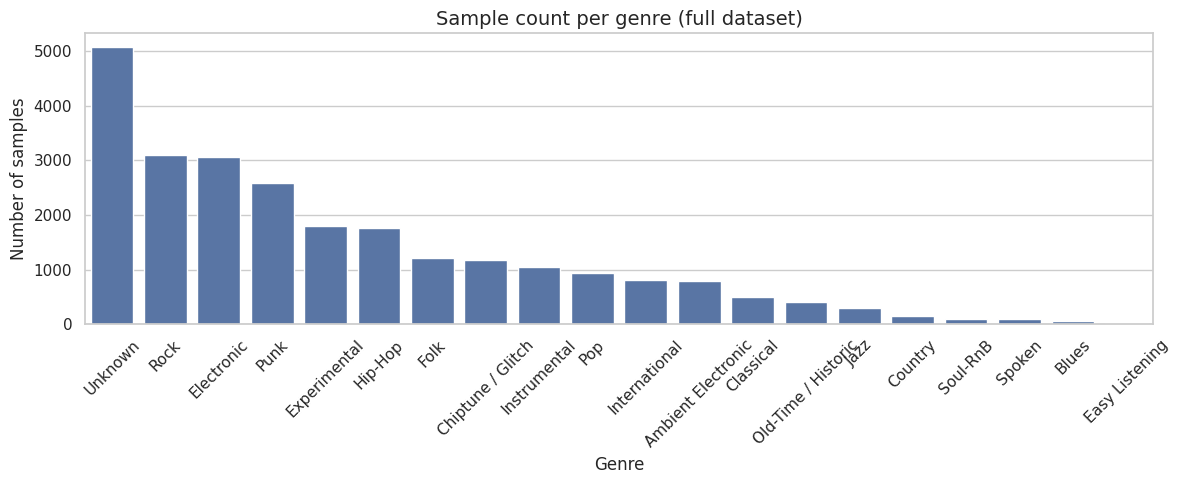

Saved → /kaggle/working/figures/genre_distribution.png


In [3]:
df = pd.DataFrame({"genre": ds["genre"]})
genre_counts = df["genre"].value_counts().reset_index()
genre_counts.columns = ["genre", "count"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=genre_counts, x="genre", y="count", order=genre_counts["genre"], ax=ax)
ax.set_title("Sample count per genre (full dataset)", fontsize=14)
ax.set_xlabel("Genre")
ax.set_ylabel("Number of samples")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(FIGURES / "genre_distribution.png", dpi=150)
plt.show()
print(f"Saved → {FIGURES / 'genre_distribution.png'}")

## 4. Sample count per genre — table

Print the exact numbers so we can spot any severely under-represented genres that should be filtered out.

In [4]:
genre_counts["pct"] = (genre_counts["count"] / genre_counts["count"].sum() * 100).round(2)
genre_counts.index = range(1, len(genre_counts) + 1)
print(genre_counts.to_string())

                  genre  count    pct
1               Unknown   5076  20.32
2                  Rock   3095  12.39
3            Electronic   3071  12.29
4                  Punk   2582  10.33
5          Experimental   1800   7.20
6               Hip-Hop   1757   7.03
7                  Folk   1214   4.86
8     Chiptune / Glitch   1181   4.73
9          Instrumental   1044   4.18
10                  Pop    945   3.78
11        International    814   3.26
12   Ambient Electronic    796   3.19
13            Classical    495   1.98
14  Old-Time / Historic    408   1.63
15                 Jazz    306   1.22
16              Country    142   0.57
17             Soul-RnB     94   0.38
18               Spoken     94   0.38
19                Blues     58   0.23
20       Easy Listening     13   0.05


## 5. Waveform visualisation

Plot one raw waveform per genre for Electronic, Classical, and Hip-Hop. This gives a qualitative feel for amplitude envelope differences between genres.

Saved → /kaggle/working/figures/waveforms_sample.png


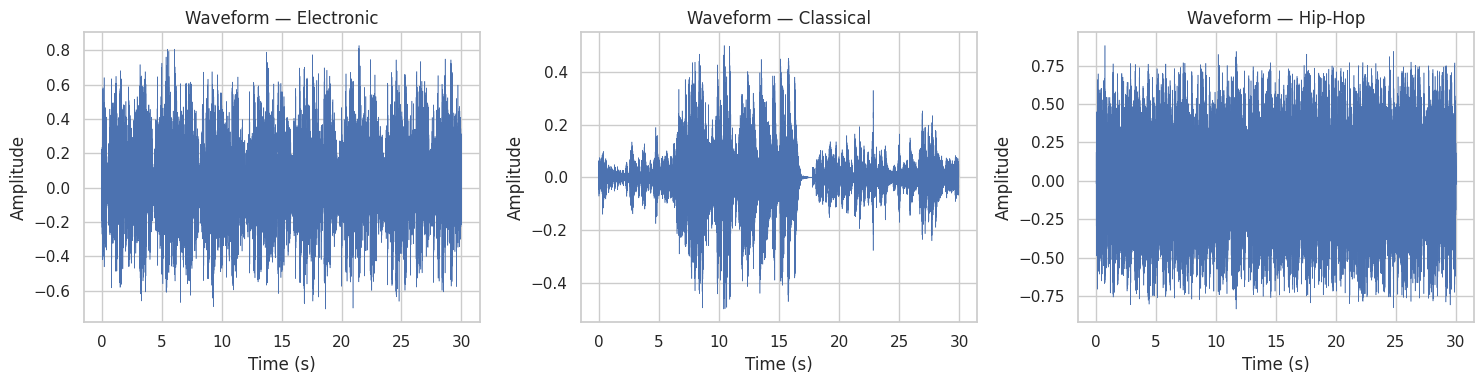

In [5]:
GENRES_DEMO = ["Electronic", "Classical", "Hip-Hop"]

def get_first_example(dataset, genre_name):
    """Return the first example matching genre_name."""
    for ex in dataset:
        if ex["genre"] == genre_name:
            return ex
    raise ValueError(f"Genre not found: {genre_name}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, genre in zip(axes, GENRES_DEMO):
    ex = get_first_example(ds, genre)
    audio_array = np.array(ex["audio"]["array"], dtype=np.float32)
    sr = ex["audio"]["sampling_rate"]
    t = np.linspace(0, len(audio_array) / sr, num=len(audio_array))
    ax.plot(t, audio_array, linewidth=0.4)
    ax.set_title(f"Waveform — {genre}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

plt.tight_layout()
fig.savefig(FIGURES / "waveforms_sample.png", dpi=150)
print(f"Saved → {FIGURES / 'waveforms_sample.png'}")
plt.show()

## 6. Mel-spectrogram visualisation

Compute and plot mel-spectrograms for the same three genres. These are the exact input representations that Pipeline A (CNN) will consume — visualising them confirms the preprocessing is producing sensible outputs.

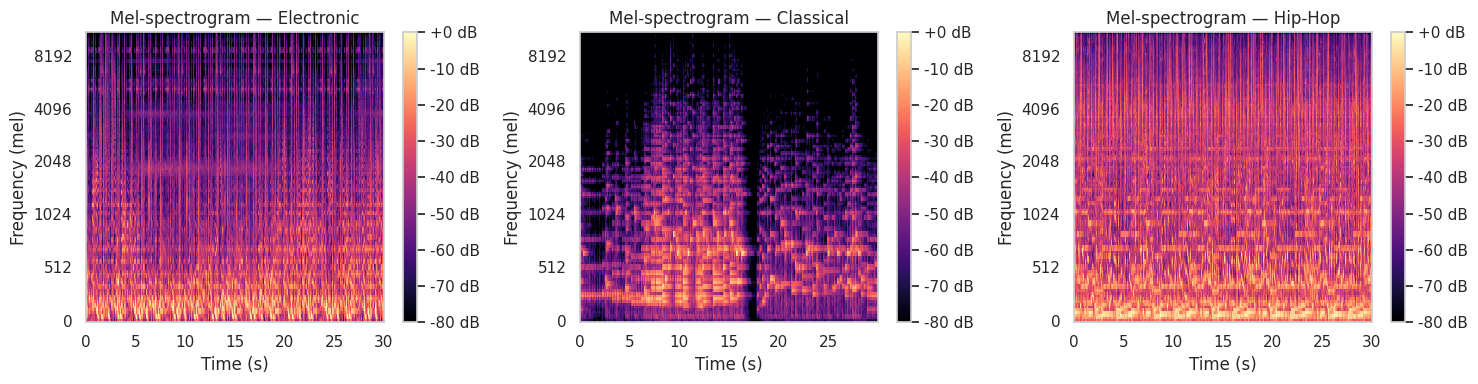

Saved → /kaggle/working/figures/spectrograms_sample.png


In [6]:
N_MELS = 128
HOP_LENGTH = 512

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, genre in zip(axes, GENRES_DEMO):
    ex = get_first_example(ds, genre)
    audio_array = np.array(ex["audio"]["array"], dtype=np.float32)
    sr = ex["audio"]["sampling_rate"]

    # Resample to librosa default if needed
    if sr != SAMPLE_RATE:
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=SAMPLE_RATE)

    mel = librosa.feature.melspectrogram(
        y=audio_array, sr=SAMPLE_RATE, n_mels=N_MELS, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    img = librosa.display.specshow(
        mel_db, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
        x_axis="time", y_axis="mel", ax=ax
    )
    ax.set_title(f"Mel-spectrogram — {genre}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (mel)")
    fig.colorbar(img, ax=ax, format="%+2.0f dB")

plt.tight_layout()
fig.savefig(FIGURES / "spectrograms_sample.png", dpi=150)
plt.show()
print(f"Saved → {FIGURES / 'spectrograms_sample.png'}")

## 7. Genre filtering

Remove eight genres that are either too small, stylistically ambiguous, or ill-suited for the classification task. The table below summarises the rationale for each:

| Genre | Reason |
|---|---|
| Unknown | No meaningful label (≈20 % of the dataset) |
| Easy Listening | Only 13 samples — too few to learn from |
| Blues | Only 58 samples — statistically unreliable |
| Soul-RnB | Only 94 samples — statistically unreliable |
| Spoken | Not music — a different modality entirely |
| Old-Time / Historic | Vague, inconsistent labelling across clips |
| Ambient Electronic | Overlaps acoustically with Electronic |
| International | Ill-defined catch-all with no consistent acoustic identity |

**Final dataset: 12 genres.**

In [7]:
REMOVE_GENRES = {
    "Spoken", "Old-Time / Historic", "Ambient Electronic",
    "Unknown", "Easy Listening", "Blues", "Soul-RnB", "International"
}

print(f"Before filtering: {len(ds):,} samples, {df['genre'].nunique()} genres")

ds_filtered = ds.filter(lambda ex: ex["genre"] not in REMOVE_GENRES)
df_filtered = pd.DataFrame({"genre": ds_filtered["genre"]})

print(f"After filtering : {len(ds_filtered):,} samples, {df_filtered['genre'].nunique()} genres")
print(f"Removed genres  : {sorted(REMOVE_GENRES)}")

Before filtering: 24,985 samples, 20 genres


Filter:   0%|          | 0/24985 [00:00<?, ? examples/s]

After filtering : 17,632 samples, 12 genres
Removed genres  : ['Ambient Electronic', 'Blues', 'Easy Listening', 'International', 'Old-Time / Historic', 'Soul-RnB', 'Spoken', 'Unknown']


## 8. Final class distribution — filtered dataset

Re-plot the genre bar chart after filtering to confirm a cleaner distribution. This is the distribution our models will actually train on.

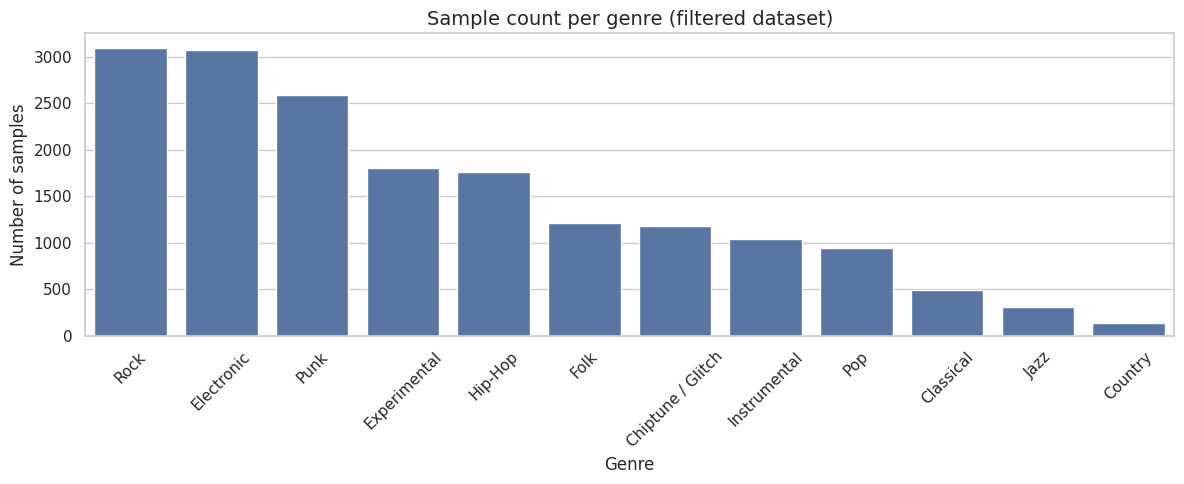

Saved → /kaggle/working/figures/genre_distribution_filtered.png


In [8]:
genre_counts_f = df_filtered["genre"].value_counts().reset_index()
genre_counts_f.columns = ["genre", "count"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=genre_counts_f, x="genre", y="count",
    order=genre_counts_f["genre"], ax=ax
)
ax.set_title("Sample count per genre (filtered dataset)", fontsize=14)
ax.set_xlabel("Genre")
ax.set_ylabel("Number of samples")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(FIGURES / "genre_distribution_filtered.png", dpi=150)
plt.show()
print(f"Saved → {FIGURES / 'genre_distribution_filtered.png'}")

## 9. Summary

Print a concise summary of the EDA findings: total samples after filtering, genres kept/removed, and expected split sizes for the 70/15/15 stratified split that all pipelines will use.

In [9]:
n_total = len(ds_filtered)
genres_kept = sorted(df_filtered["genre"].unique())
genres_removed = sorted(REMOVE_GENRES)

n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)
n_test  = n_total - n_train - n_val

print("=" * 45)
print("EDA SUMMARY")
print("=" * 45)
print(f"Total samples (filtered) : {n_total:,}")
print(f"Genres kept              : {len(genres_kept)} (of 20 original)")
for g in genres_kept:
    print(f"  {g}")
print(f"Genres removed           : {len(genres_removed)}")
for g in genres_removed:
    print(f"  {g}")
print()
print("Expected split sizes (70 / 15 / 15 stratified):")
print(f"  Train : {n_train:,}")
print(f"  Val   : {n_val:,}")
print(f"  Test  : {n_test:,}")
print("=" * 45)

EDA SUMMARY
Total samples (filtered) : 17,632
Genres kept              : 12 (of 20 original)
  Chiptune / Glitch
  Classical
  Country
  Electronic
  Experimental
  Folk
  Hip-Hop
  Instrumental
  Jazz
  Pop
  Punk
  Rock
Genres removed           : 8
  Ambient Electronic
  Blues
  Easy Listening
  International
  Old-Time / Historic
  Soul-RnB
  Spoken
  Unknown

Expected split sizes (70 / 15 / 15 stratified):
  Train : 12,342
  Val   : 2,644
  Test  : 2,646


## 10. Class imbalance analysis

Visualise the sample counts for all 12 remaining genres to quantify the imbalance. The dashed red line marks the mean count; bars to the left represent under-represented genres that may need compensating class weights during training.

Saved → /kaggle/working/figures/class_imbalance.png

Largest class  : Rock (3,095 samples)
Smallest class : Country (142 samples)
Imbalance ratio: 21.8×
Class weights will be applied in the loss function during training to compensate for this imbalance.


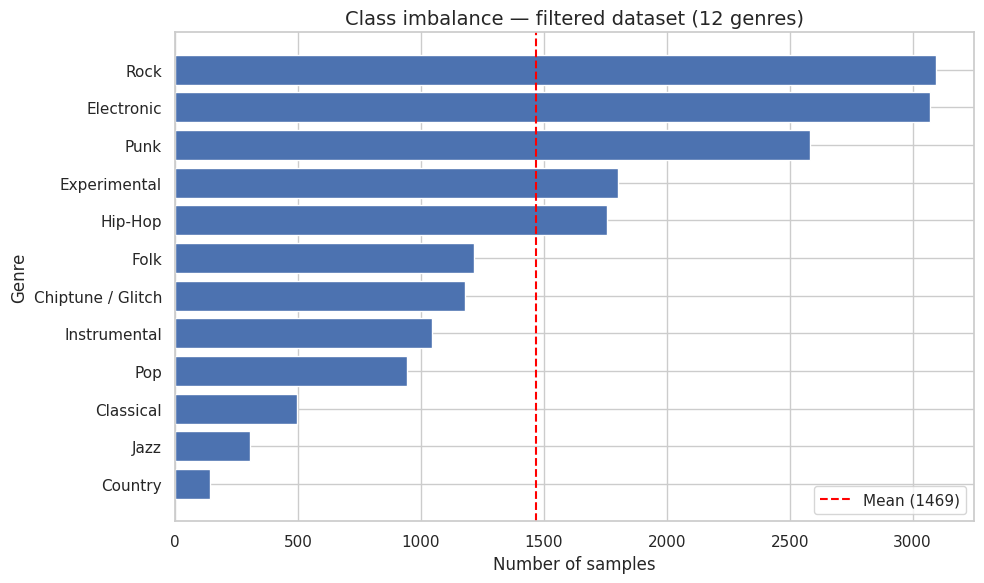

In [10]:
genre_counts_f = df_filtered["genre"].value_counts().reset_index()
genre_counts_f.columns = ["genre", "count"]

largest = genre_counts_f.iloc[0]
smallest = genre_counts_f.iloc[-1]
imbalance_ratio = largest["count"] / smallest["count"]
mean_count = genre_counts_f["count"].mean()

fig, ax = plt.subplots(figsize=(10, 6))
genre_counts_sorted = genre_counts_f.sort_values("count", ascending=False)
ax.barh(genre_counts_sorted["genre"], genre_counts_sorted["count"])
ax.axvline(mean_count, color="red", linestyle="--", linewidth=1.5, label=f"Mean ({mean_count:.0f})")
ax.set_title("Class imbalance — filtered dataset (12 genres)", fontsize=14)
ax.set_xlabel("Number of samples")
ax.set_ylabel("Genre")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIGURES / "class_imbalance.png", dpi=150)
print(f"Saved → {FIGURES / 'class_imbalance.png'}")

print(f"\nLargest class  : {largest['genre']} ({largest['count']:,} samples)")
print(f"Smallest class : {smallest['genre']} ({smallest['count']:,} samples)")
print(f"Imbalance ratio: {imbalance_ratio:.1f}×")
print("Class weights will be applied in the loss function during training to compensate for this imbalance.")
plt.show()

## 11. Mel-spectrogram grid — all 12 genres

One example mel-spectrogram per genre, arranged in a 4 × 3 grid. This confirms that each genre produces a visually distinct spectrogram pattern, validating the CNN approach.

Saved → /kaggle/working/figures/spectrograms_all_genres.png


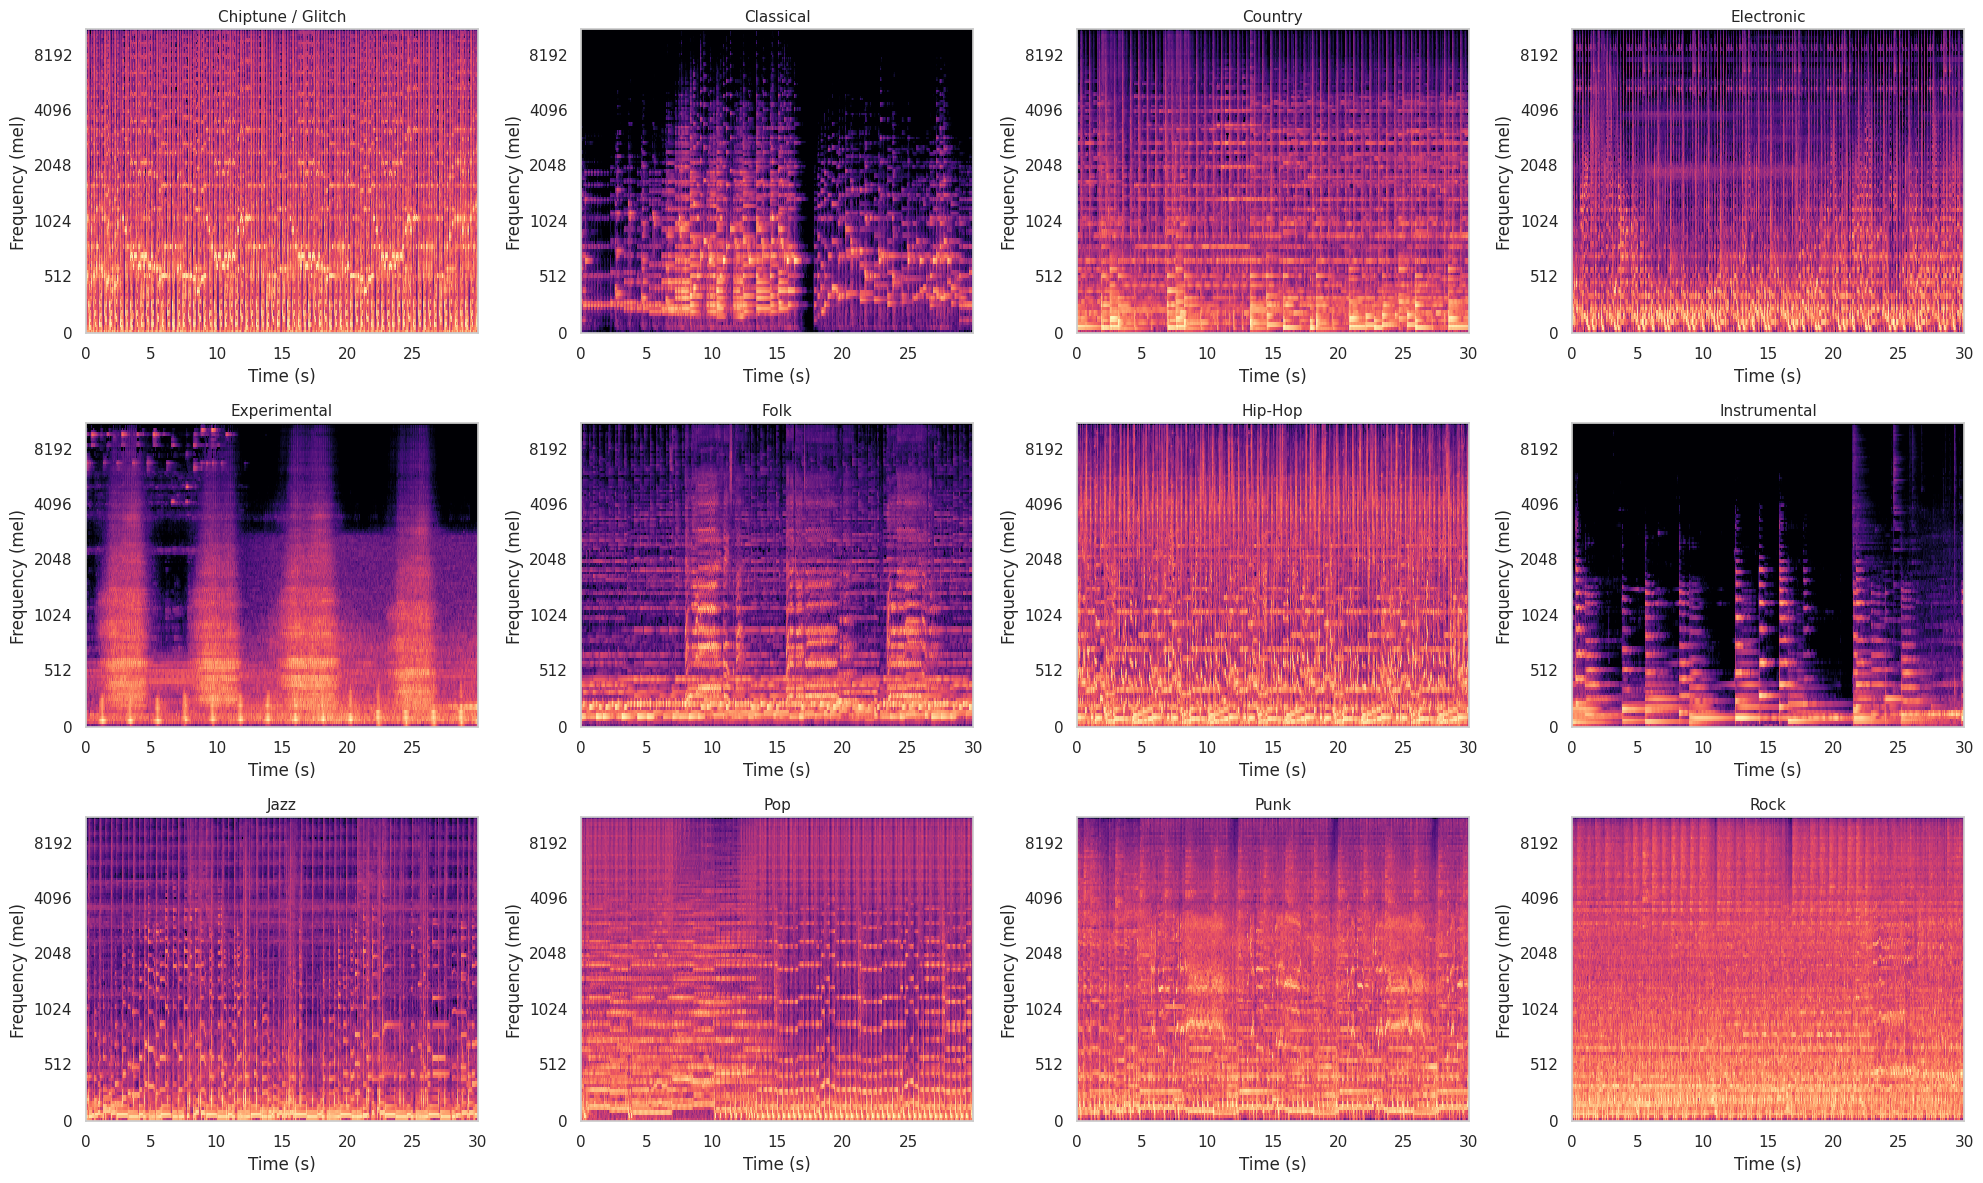

In [11]:
N_MELS = 128
HOP_LENGTH = 512
genres_all = sorted(df_filtered["genre"].unique())

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes_flat = axes.flatten()

for idx, genre in enumerate(genres_all):
    ax = axes_flat[idx]
    ex = get_first_example(ds_filtered, genre)
    audio_array = np.array(ex["audio"]["array"], dtype=np.float32)
    sr = ex["audio"]["sampling_rate"]

    if sr != SAMPLE_RATE:
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=SAMPLE_RATE)

    mel = librosa.feature.melspectrogram(
        y=audio_array, sr=SAMPLE_RATE, n_mels=N_MELS, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    img = librosa.display.specshow(
        mel_db, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
        x_axis="time", y_axis="mel", ax=ax
    )
    ax.set_title(genre, fontsize=11)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (mel)")

plt.tight_layout()
fig.savefig(FIGURES / "spectrograms_all_genres.png", dpi=150)
print(f"Saved → {FIGURES / 'spectrograms_all_genres.png'}")
plt.show()